# Customer Churn — In-Class Assignment
## This week: CRISP-DM Phase 2 — Data Understanding

### Learning goal
Develop a defensible understanding of the churn dataset **before changing the data or building a model**.

By the end of the session you should be able to:
- explain what the dataset represents;
- identify the target variable and calculate the churn rate;
- explain the business meaning of churn and class imbalance;
- explain why actual churners can easily be missed;
- explore relationships between customer characteristics and churn;
- identify data-quality concerns;
- formulate evidence-based findings and questions for the next CRISP-DM phases.

### Boundary for this week
**Do not clean, transform, encode, scale, impute, delete rows, engineer features or build a model.**

You may identify possible data-quality issues, but you leave the original dataset unchanged.

## 1. Business context

The company wants to understand customer churn.

A customer with `Churned = 1` has left the company.  
A customer with `Churned = 0` has remained.

Before predicting churn, management needs to understand:
1. How large is the churn problem?
2. What characteristics distinguish churners from non-churners?
3. Which patterns deserve further investigation?
4. What limitations or quality concerns exist in the available data?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("in_class_customer_churn_dataset.csv")
df.head()

,Customer_ID,Age,Gender,Region,Tenure_Months,Annual_Spend,Promo_Used,Customer_Service_Calls,Churned
0,1,56,Female,South,58,2393.95,1,3,0
1,2,69,Male,South,28,4853.96,1,4,0
2,3,46,Male,North,36,4569.16,1,4,0
3,4,32,Male,East,26,3768.50,1,1,0
4,5,60,Male,South,8,2867.84,1,3,0


## 2. Understand the structure

Answer after running the cells:
- What does one row represent?
- What does one column represent?
- How many customers and variables are present?
- Which column is an identifier?
- Which column is the business outcome/target?

In [4]:
print("Shape:", df.shape)
df.info()

Shape: (300, 9)
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             300 non-null    int64  
 1   Age                     300 non-null    int64  
 2   Gender                  300 non-null    str    
 3   Region                  300 non-null    str    
 4   Tenure_Months           300 non-null    int64  
 5   Annual_Spend            300 non-null    float64
 6   Promo_Used              300 non-null    int64  
 7   Customer_Service_Calls  300 non-null    int64  
 8   Churned                 300 non-null    int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 21.2 KB


In [5]:
df.nunique(dropna=False).sort_values()

Gender                      2
Promo_Used                  2
Churned                     2
Region                      4
Customer_Service_Calls     10
Age                        51
Tenure_Months              59
Customer_ID               300
Annual_Spend              300
dtype: int64

### Your answer
Write your interpretation here in Markdown.

**Observation unit:**  
300

**Identifier:**  
Customor_ID

**Target:**  
Churned

**Dataset dimensions:**  
300 rows and 9 columns

## 3. Understand the variables

Create a short data dictionary. For each variable state:
- likely business meaning;
- type: identifier, numerical, categorical, binary or target;
- whether it may plausibly contain information related to churn.

Do not transform variables.

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,300.0,NaN,NaN,NaN,150.5,86.746758,1.0,75.75,150.5,225.25,300.0
Age,300.0,NaN,NaN,NaN,43.32,15.326686,18.0,30.0,43.5,56.0,69.0
Gender,300,2,Female,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,300,4,North,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure_Months,300.0,NaN,NaN,NaN,30.283333,17.282902,1.0,16.0,29.5,47.0,59.0
Annual_Spend,300.0,NaN,NaN,NaN,4079.818533,855.815166,1772.29,3489.35,4094.535,4657.0325,6380.96
Promo_Used,300.0,NaN,NaN,NaN,0.623333,0.48536,0.0,0.0,1.0,1.0,1.0
Customer_Service_Calls,300.0,NaN,NaN,NaN,4.0,2.214274,0.0,2.0,4.0,5.0,9.0
Churned,300.0,NaN,NaN,NaN,0.316667,0.465953,0.0,0.0,0.0,1.0,1.0


### Initial descriptive observations
Record at least **three observations** about ranges, typical values, variation or categories.

1. customor age is inbetween 18 and 69 the mean is 43.3
2. the tenure month is a minimum of 1 and a max of 59 with a mean of 30.3
3. the anual spend is a minimum of 1772.29 a max of 6380.96 and a mean of 4079.82

If something looks unusual, record it as a **data-quality question**, not as something to fix today.

# 4. Churn rate

The churn rate answers:

> **What proportion of the observed customers actually churned?**

\[
\text{Churn Rate} = \frac{\text{Number of Churners}}{\text{Total Customers}}
\]

Calculate the counts and percentages.

In [7]:
churn_counts = df["Churned"].value_counts().sort_index()
churn_pct = df["Churned"].value_counts(normalize=True).sort_index() * 100

print("Counts:")
print(churn_counts)
print("\nPercentages:")
print(churn_pct.round(2))
print(f"\nOverall churn rate: {df['Churned'].mean():.2%}")

Counts:
Churned
0    205
1     95
Name: count, dtype: int64

Percentages:
Churned
0    68.33
1    31.67
Name: proportion, dtype: float64

Overall churn rate: 31.67%


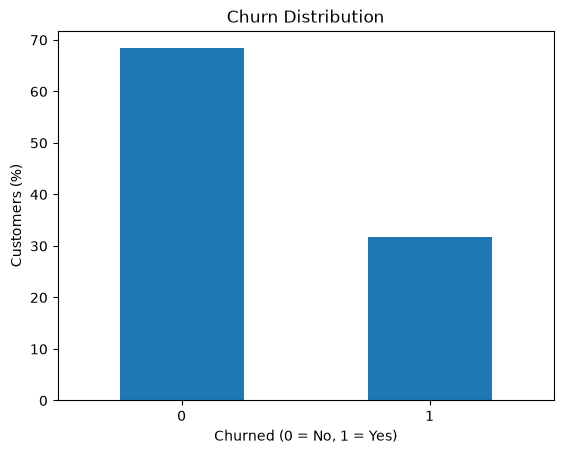

In [8]:
ax = churn_pct.plot(kind="bar")
ax.set_title("Churn Distribution")
ax.set_xlabel("Churned (0 = No, 1 = Yes)")
ax.set_ylabel("Customers (%)")
plt.xticks(rotation=0)
plt.show()

### Interpret the churn rate

Answer in business language:

1. What is the churn rate? the churn rate is 31.67%
2. What does that percentage mean? 31.67% Has stopped there subscribtion
3. If the company had 10,000 comparable customers and the same rate continued, approximately how many would churn? 3167 customors would churn
4. Is churn the majority or minority outcome? Minority
5. Can you conclude from this dataset alone that the churn rate is commercially unacceptable? Explain what additional context would be needed. no you need the targets from last year, what the competition is doing and the cost to keep customors

# 5. Why actual churners can be missed

Suppose a future model predicts **“No churn” for every customer**.

Because most customers do not churn, that rule can still achieve apparently reasonable accuracy.

Calculate the accuracy of this deliberately poor rule.

In [9]:
naive_accuracy = (df["Churned"] == 0).mean()
actual_churners = (df["Churned"] == 1).sum()

print(f"Naive accuracy: {naive_accuracy:.2%}")
print(f"Actual churners: {actual_churners}")
print(f"Actual churners missed: {actual_churners}")
print("Share of actual churners missed: 100%")

Naive accuracy: 68.33%
Actual churners: 95
Actual churners missed: 95
Share of actual churners missed: 100%


### Discuss

- Why is **68.33% accuracy** misleading in this example? because the 
- What happens to the 95 actual churners?
- What could the business lose if customers who will churn are classified as non-churners?
- Why will we eventually need to look beyond accuracy when evaluating a churn model?

A missed actual churner is called a **false negative**. You do not need to calculate model metrics today; the purpose is to understand the business risk created by the target distribution.

# 6. Explore relationships with churn

For each analysis:
1. describe what you observe;
2. compare churners and non-churners;
3. connect the observation to the business problem;
4. do **not** claim causation.

In [10]:
# Numerical variables: compare churners and non-churners
numeric_vars = ["Age", "Tenure_Months", "Annual_Spend", "Customer_Service_Calls"]
df.groupby("Churned")[numeric_vars].agg(["mean", "median"]).round(2)

Age        Tenure_Months        Annual_Spend           \
          mean median          mean median         mean   median   
Churned                                                            
0        42.94   43.0         31.99   32.0      4298.71  4261.14   
1        44.14   44.0         26.61   28.0      3607.48  3413.65   

        Customer_Service_Calls         
                          mean median  
Churned                                
0                         3.70    3.0  
1                         4.65    5.0

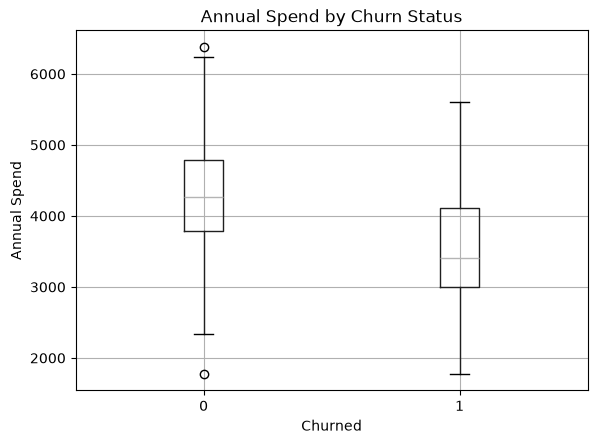

In [11]:
# Annual spend
df.boxplot(column="Annual_Spend", by="Churned")
plt.title("Annual Spend by Churn Status")
plt.suptitle("")
plt.xlabel("Churned")
plt.ylabel("Annual Spend")
plt.show()

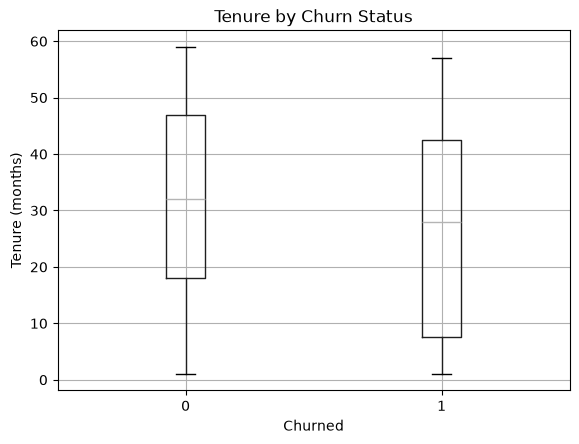

In [12]:
# Tenure
df.boxplot(column="Tenure_Months", by="Churned")
plt.title("Tenure by Churn Status")
plt.suptitle("")
plt.xlabel("Churned")
plt.ylabel("Tenure (months)")
plt.show()

,customers,churn_rate,churn_rate_pct
Customer_Service_Calls,,,
0,9,0.111111,11.111111
1,28,0.178571,17.857143
2,43,0.255814,25.581395
3,60,0.316667,31.666667
4,50,0.160000,16.000000
5,37,0.513514,51.351351
6,25,0.360000,36.000000
7,25,0.480000,48.000000
8,11,0.545455,54.545455


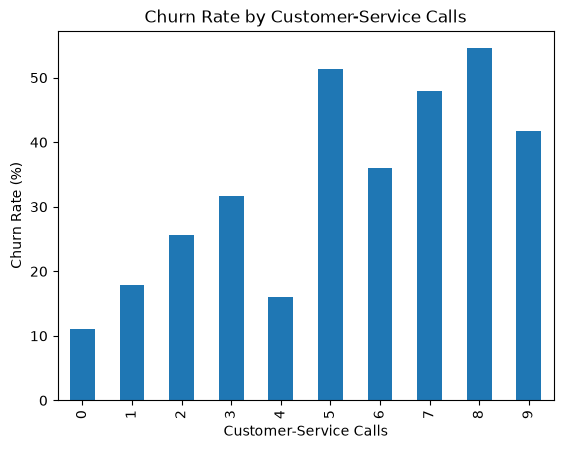

In [13]:
# Service calls
service = df.groupby("Customer_Service_Calls").agg(
    customers=("Customer_ID","count"),
    churn_rate=("Churned","mean")
)
service["churn_rate_pct"] = service["churn_rate"] * 100
display(service)

service["churn_rate_pct"].plot(kind="bar")
plt.title("Churn Rate by Customer-Service Calls")
plt.xlabel("Customer-Service Calls")
plt.ylabel("Churn Rate (%)")
plt.show()

In [14]:
# Categorical variables
for variable in ["Gender", "Region", "Promo_Used"]:
    summary = df.groupby(variable).agg(
        customers=("Customer_ID","count"),
        churn_rate=("Churned","mean")
    )
    summary["churn_rate_pct"] = summary["churn_rate"] * 100
    print(f"\n--- {variable} ---")
    display(summary.round(3))


--- Gender ---


,customers,churn_rate,churn_rate_pct
Gender,,,
Female,162,0.346,34.568
Male,138,0.283,28.261



--- Region ---


,customers,churn_rate,churn_rate_pct
Region,,,
East,68,0.426,42.647
North,90,0.256,25.556
South,65,0.338,33.846
West,77,0.273,27.273



--- Promo_Used ---


,customers,churn_rate,churn_rate_pct
Promo_Used,,,
0,113,0.319,31.858
1,187,0.316,31.551


### Evidence-based findings

Write at least **three findings**.

For each finding use this structure:

**Evidence:** What did you observe?  
**Interpretation:** What might this mean for the business?  
**Caution:** What can you *not* conclude from this relationship?

1. ...
2. ...
3. ...

# 7. Data-quality understanding

Data Understanding also asks whether the available data appears suitable and trustworthy.

**Observe only. Do not fix anything.**

In [15]:
quality = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique(dropna=False)
})
display(quality)

print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate Customer_ID values:", df["Customer_ID"].duplicated().sum())

,data_type,missing_values,unique_values
Customer_ID,int64,0,300
Age,int64,0,51
Gender,str,0,2
Region,str,0,4
Tenure_Months,int64,0,59
Annual_Spend,float64,0,300
Promo_Used,int64,0,2
Customer_Service_Calls,int64,0,10
Churned,int64,0,2


Exact duplicate rows: 0
Duplicate Customer_ID values: 0


In [16]:
for col in ["Gender", "Region", "Promo_Used", "Churned"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


Gender:
Gender
Female    162
Male      138
Name: count, dtype: int64

Region:
Region
North    90
West     77
East     68
South    65
Name: count, dtype: int64

Promo_Used:
Promo_Used
1    187
0    113
Name: count, dtype: int64

Churned:
Churned
0    205
1     95
Name: count, dtype: int64


In [17]:
df[["Age", "Tenure_Months", "Annual_Spend", "Customer_Service_Calls"]].agg(["min","max","mean","median"]).T

,min,max,mean,median
Age,18.00,69.00,43.320000,43.500
Tenure_Months,1.00,59.00,30.283333,29.500
Annual_Spend,1772.29,6380.96,4079.818533,4094.535
Customer_Service_Calls,0.00,9.00,4.000000,4.000


### Data-quality findings

Record what you found. Do **not** propose or execute cleaning code.

| Observation / concern | Variable(s) | Evidence | Why it could matter |
|---|---|---|---|
|  |  |  |  |
|  |  |  |  |
|  |  |  |  |

If you find no issue in a category, that is also a valid finding.

# 8. Final Data Understanding conclusion

Complete this section in Markdown.

### A. Churn situation
- Churn rate:
- Number of churners:
- Business meaning:

### B. Risk of missing churners
Explain why a seemingly acceptable accuracy can still be poor for the churn problem.

### C. Three strongest observations
1. ...
2. ...
3. ...

### D. Data-quality observations
...

### E. Limitations
What important information is absent or cannot be concluded from this dataset?

### F. Questions to carry forward
What should be investigated in the next CRISP-DM stages?

---

## End of this week's work

**Stop here.**

This week is **Data Understanding only**.  
Next week you will use these findings when you combine **Data Preparation and Modelling**.